# Тест примеры для поиска лучших узлов полным перебором

In [1]:
import numpy as np

import osmnx as ox
import networkx as nx
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from genesis.best_points import NodeMetric, BestNodesFull
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.states import FirstArrivalUnitState
from genesis.utils import *
from genesis.tools import k_v_dict
from genesis.swiss_knife import CMAP_GrGldRd

In [2]:
def load_G():
    return ox.load_graphml("tests/data/test_rng.ml")

def load_area():
    return gpd.read_file("tests/data/test_polygon.gpkg")

def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G

# Примеры

## Для малого графа

### Прибытие во все узлы

In [3]:
G = create_G()

best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), ArrivalTime())(G)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), ArrivalTime(np.max))(G)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), CoverIndex())(G)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), CoverIndex(20))(G)
print(best_nodes, best_metric)

[1] 9.666666666666666
[4] 18.0
[1] 60.0
[4] 100.0


### Прибытие только в некоторые узлы (область)

In [4]:
points_mask = {
    1:False,
    2:False,
    3:False,
    4:True,
    5:True,
    6:True,
    7:True,
    8:True,
    9:True,
    10:True,
    11:True,
    12:False,
    13:False,
    14:False,
    15:False
}
points_mask = pd.Series(points_mask)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), ArrivalTime())(G, area=points_mask)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), ArrivalTime(np.max))(G, area=points_mask)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), CoverIndex())(G, area=points_mask)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), CoverIndex(20))(G, area=points_mask)
print(best_nodes, best_metric)

[3] 8.0
[3, 4] 13.0
[2] 85.71428571428571
[1, 2, 3, 4] 100.0


### Расчет только указанных узлов

In [5]:
nodes_for_calc = [1,4,7,9,10,11,12]

best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), ArrivalTime())(G, nodes_list=nodes_for_calc)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), ArrivalTime(np.max))(G, nodes_list=nodes_for_calc)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), CoverIndex())(G, nodes_list=nodes_for_calc)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), CoverIndex(20))(G, nodes_list=nodes_for_calc)
print(best_nodes, best_metric)

[1] 9.666666666666666
[4] 18.0
[1] 60.0
[4] 100.0


### Расчет только указанных узлов для прибытия в некоторые узлы (область)

In [9]:
nodes_for_calc = [1,4,5,6,7,8,14]
# nodes_for_calc = [1,5]
# nodes_for_calc = [1,4,7,9,10,11,12]

best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), ArrivalTime())(G, area=points_mask, nodes_list=nodes_for_calc)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), ArrivalTime(np.max))(G, area=points_mask, nodes_list=nodes_for_calc)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), CoverIndex())(G, area=points_mask, nodes_list=nodes_for_calc)
print(best_nodes, best_metric)
best_nodes, best_metric = BestNodesFull(FirstArrivalUnitState(), CoverIndex(20))(G, area=points_mask, nodes_list=nodes_for_calc)
print(best_nodes, best_metric)

[4] 8.125
[4] 13.0
[1] 75.0
[1, 4] 100.0


## Для большого графа

In [10]:
G = load_G()
area = load_area()

### Эталонное размещение

Для всех узлов графа, при допустимом охвате графа не менее 95%.

In [46]:
test_nodes = list(G.nodes())
metric_at_mean = {}
metric_at_max = {}
metric_ci_10 = {}
metric_ci_20 = {}

g_number_of_nodes = len(test_nodes)
appr_val=0.95
appr_nodes=g_number_of_nodes*appr_val

for i, test_node in enumerate(test_nodes):
    print(round(i/g_number_of_nodes,3), end='\r')
    times, _ = FirstArrivalUnitState()(G, points=[test_node])
    if len(times)>=appr_nodes:
        metric_at_mean[test_node] = ArrivalTime()(times)
        metric_at_max[test_node] = ArrivalTime(np.max)(times)
        metric_ci_10[test_node] = CoverIndex()(times)
        metric_ci_20[test_node] = CoverIndex(20)(times)      
print('ready')

nx.set_node_attributes(G, pd.Series(metric_at_mean, dtype=float), 'metric_at_mean')
nx.set_node_attributes(G, pd.Series(metric_at_max, dtype=float), 'metric_at_max')
nx.set_node_attributes(G, pd.Series(metric_ci_10, dtype=float), 'metric_ci_10')
nx.set_node_attributes(G, pd.Series(metric_ci_20, dtype=float), 'metric_ci_20')

print('metric_at_mean', k_v_dict(metric_at_mean), min(metric_at_mean.values()), sep='\t')
print('metric_at_max', k_v_dict(metric_at_max), min(metric_at_max.values()), sep='\t')
print('metric_ci_10', k_v_dict(metric_ci_10, max), max(metric_ci_10.values()), sep='\t')
print('metric_ci_20', k_v_dict(metric_ci_20, max), max(metric_ci_20.values()), sep='\t')

ready
metric_at_mean	426923808	8.355415617070701
metric_at_max	4116049991	18.03619171428572
metric_ci_10	3981463776	67.53270348837209
metric_ci_20	426923809	100.0


C:\Users\obsid\AppData\Local\Temp\ipykernel_10140\3178367252.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  axs[0,0].text(float(crds.x), float(crds.y), str(best_node))
C:\Users\obsid\AppData\Local\Temp\ipykernel_10140\3178367252.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  axs[0,1].text(float(crds.x), float(crds.y), str(best_node))


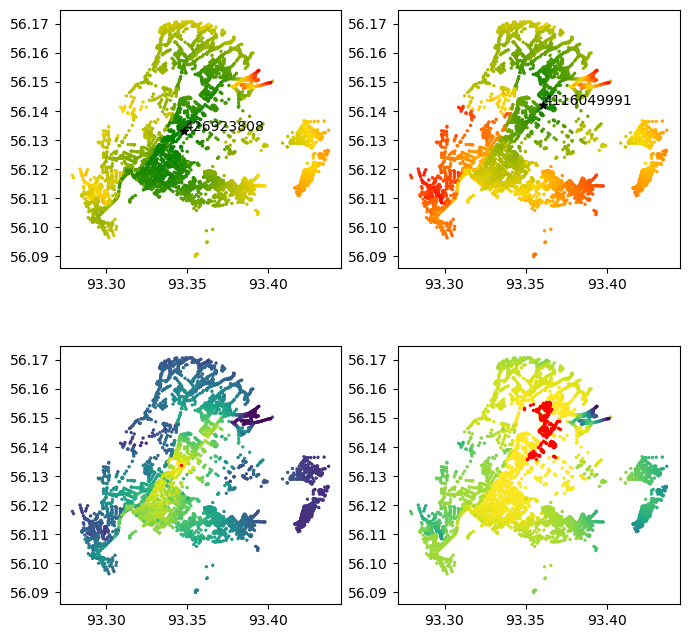

In [48]:
nodes = ox.graph_to_gdfs(G, edges=False)

fig, axs = plt.subplots(2,2, figsize=(8,8))
best_node=426923808
nodes.plot(column='metric_at_mean', markersize=2, ax=axs[0,0], cmap=CMAP_GrGldRd)
nodes.loc[[best_node]].plot(c='k', marker="*", ax=axs[0,0])
crds = nodes.loc[[best_node]].geometry
axs[0,0].text(float(crds.x), float(crds.y), str(best_node))

best_node=4116049991
nodes.plot(column='metric_at_max', markersize=2, ax=axs[0,1], cmap=CMAP_GrGldRd)
nodes.loc[[best_node]].plot(c='k', marker="*", ax=axs[0,1])
crds = nodes.loc[[best_node]].geometry
axs[0,1].text(float(crds.x), float(crds.y), str(best_node))

best_nodes=nodes[nodes['metric_ci_10']==max(nodes['metric_ci_10'])]
nodes.plot(column='metric_ci_10', markersize=2, ax=axs[1,0])    #, cmap=CMAP_RdGldGr
best_nodes.plot(c='r', markersize=2, ax=axs[1,0])

best_nodes=nodes[nodes['metric_ci_20']==max(nodes['metric_ci_20'])]
nodes.plot(column='metric_ci_20', markersize=2, ax=axs[1,1])    #, cmap=CMAP_RdGldGr
best_nodes.plot(c='r', markersize=2, ax=axs[1,1])

plt.show()

Для всех узлов графа, при допустимом охвате области `area` не менее 95%. Метрика рассчитывается только для узлов `area`.

In [50]:
test_nodes = list(G.nodes())
metric_at_mean = {}
metric_at_max = {}
metric_ci_10 = {}
metric_ci_20 = {}

g_nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = g_nodes.within(area.iloc[0].geometry)

g_number_of_nodes = len(test_nodes)
appr_val=0.95
appr_nodes=points_mask.sum()*appr_val

for i, test_node in enumerate(test_nodes):
    print(round(i/g_number_of_nodes,3), end='\r')
    times, _ = FirstArrivalUnitState()(G, points=[test_node], area=points_mask)

    if len(times)>=appr_nodes:
        metric_at_mean[test_node] = ArrivalTime()(times)
        metric_at_max[test_node] = ArrivalTime(np.max)(times)
        metric_ci_10[test_node] = CoverIndex()(times)
        metric_ci_20[test_node] = CoverIndex(20)(times)
print('ready')

nx.set_node_attributes(G, pd.Series(metric_at_mean, dtype=float), 'metric_at_mean_area')
nx.set_node_attributes(G, pd.Series(metric_at_max, dtype=float), 'metric_at_max_area')
nx.set_node_attributes(G, pd.Series(metric_ci_10, dtype=float), 'metric_ci_10_area')
nx.set_node_attributes(G, pd.Series(metric_ci_20, dtype=float), 'metric_ci_20_area')

print('metric_at_mean', k_v_dict(metric_at_mean), min(metric_at_mean.values()), sep='\t')
print('metric_at_max', k_v_dict(metric_at_max), min(metric_at_max.values()), sep='\t')
print('metric_ci_10', k_v_dict(metric_ci_10, max), max(metric_ci_10.values()), sep='\t')
print('metric_ci_20', k_v_dict(metric_ci_20, max), max(metric_ci_20.values()), sep='\t')

ready
metric_at_mean	1577701962	4.328401644772975
metric_at_max	4116030638	11.343054285714286
metric_ci_10	2034401285	98.83772910147519
metric_ci_20	290700344	100.0


C:\Users\obsid\AppData\Local\Temp\ipykernel_10140\1334362207.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  axs[0,0].text(float(crds.x), float(crds.y), str(best_node))
C:\Users\obsid\AppData\Local\Temp\ipykernel_10140\1334362207.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  axs[0,1].text(float(crds.x), float(crds.y), str(best_node))


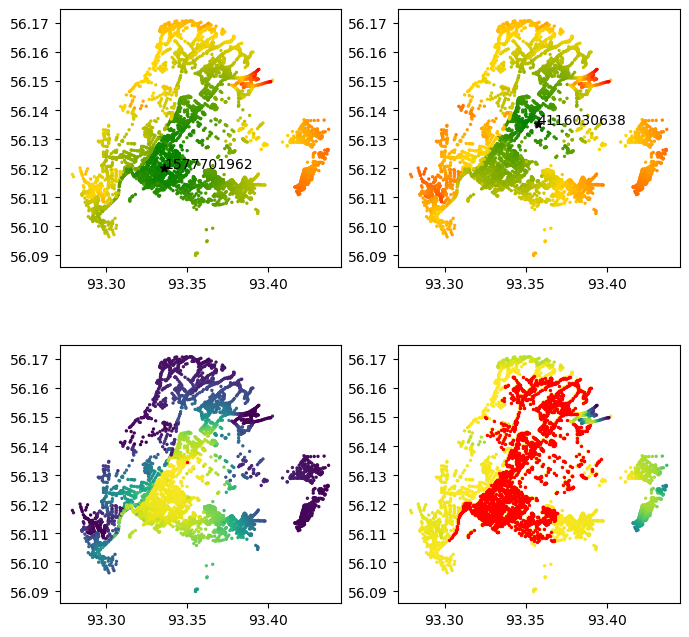

In [74]:
nodes = ox.graph_to_gdfs(G, edges=False)

fig, axs = plt.subplots(2,2, figsize=(8,8))
best_node=1577701962
nodes.plot(column='metric_at_mean_area', markersize=2, ax=axs[0,0], cmap=CMAP_GrGldRd)
nodes.loc[[best_node]].plot(c='k', marker="*", ax=axs[0,0])
crds = nodes.loc[[best_node]].geometry
axs[0,0].text(float(crds.x), float(crds.y), str(best_node))

best_node=4116030638
nodes.plot(column='metric_at_max_area', markersize=2, ax=axs[0,1], cmap=CMAP_GrGldRd)
nodes.loc[[best_node]].plot(c='k', marker="*", ax=axs[0,1])
crds = nodes.loc[[best_node]].geometry
axs[0,1].text(float(crds.x), float(crds.y), str(best_node))

best_nodes=nodes[nodes['metric_ci_10_area']==max(nodes['metric_ci_10_area'])]
nodes.plot(column='metric_ci_10_area', markersize=2, ax=axs[1,0])    #, cmap=CMAP_RdGldGr
best_nodes.plot(c='r', markersize=2, ax=axs[1,0])

best_nodes=nodes[nodes['metric_ci_20_area']==max(nodes['metric_ci_20_area'])]
nodes.plot(column='metric_ci_20_area', markersize=2, ax=axs[1,1])    #, cmap=CMAP_RdGldGr
best_nodes.plot(c='r', markersize=2, ax=axs[1,1])

plt.show()

In [83]:
ox.save_graphml(G, "tests/data/test_rng.ml")
ox.save_graph_geopackage(G, "tests/data/test_rng.gpkg")

### Все узлы графа

In [22]:
nodes = ox.graph_to_gdfs(G, edges=False)
nodes['metric_at_mean'] = nodes['metric_at_mean'].astype(float)
nodes['metric_at_max'] = nodes['metric_at_max'].astype(float)
nodes['metric_ci_10'] = nodes['metric_ci_10'].astype(float)
nodes['metric_ci_20'] = nodes['metric_ci_20'].astype(float)
nodes['metric_at_mean_area'] = nodes['metric_at_mean_area'].astype(float)
nodes['metric_at_max_area'] = nodes['metric_at_max_area'].astype(float)
nodes['metric_ci_10_area'] = nodes['metric_ci_10_area'].astype(float)
nodes['metric_ci_20_area'] = nodes['metric_ci_20_area'].astype(float)

#### Среднее время

In [57]:
pb = Progressbar(G.number_of_nodes(), bins=40)
bnf = timing(BestNodesFull(FirstArrivalUnitState(), ArrivalTime()))

best_nodes, best_metric = bnf(env=G, node_calc_end_function=pb)
print(best_nodes, best_metric)

assert best_nodes==[k_v_dict(nodes['metric_at_mean'].to_dict())]
assert best_metric==nodes['metric_at_mean'].min()

|########################################| 100.0%
ВРЕМЯ: 345.84 сек
[426923808] 8.355415617070701


#### Максимальное время

In [73]:
pb = Progressbar(G.number_of_nodes(), bins=40)
bnf = timing(BestNodesFull(FirstArrivalUnitState(), ArrivalTime(np.max)))

best_nodes, best_metric = bnf(env=G, node_calc_end_function=pb)
print(best_nodes, best_metric)

assert best_nodes==[k_v_dict(nodes['metric_at_max'].to_dict())]
assert best_metric==nodes['metric_at_max'].min()

|########################################| 100.0%
ВРЕМЯ: 332.5 сек
[4116049991] 18.03619171428572


#### ИП-10

In [79]:
pb = Progressbar(G.number_of_nodes(), bins=40)
bnf = timing(BestNodesFull(FirstArrivalUnitState(), CoverIndex()))

best_nodes, best_metric = bnf(env=G, node_calc_end_function=pb)
print(best_nodes, best_metric)

# best_nodes_check = nodes[nodes['metric_ci_10']==max(nodes['metric_ci_10'])]
best_nodes_check = [k_v_dict(nodes['metric_ci_10'].to_dict(), max)]
assert best_nodes==best_nodes_check
assert best_metric==nodes['metric_ci_10'].max()

|########################################| 100.0%
ВРЕМЯ: 374.93 сек
[3981463776] 67.53270348837209


#### ИП-20

In [ ]:
pb = Progressbar(G.number_of_nodes(), bins=40)
bnf = timing(BestNodesFull(FirstArrivalUnitState(), CoverIndex(20)))

best_nodes, best_metric = bnf(env=G, node_calc_end_function=pb)  #, nodes_list=nodes_list)
print(best_nodes, best_metric)

best_nodes_check = nodes[nodes['metric_ci_20']==max(nodes['metric_ci_20'].astype(float))]
assert best_nodes==list(best_nodes_check.index)
assert best_metric==best_nodes_check['metric_ci_20'].max()
# 'ok'

### Прибытие только в узлы некоторой области

In [ ]:
points_mask = nodes.within(area.iloc[0].geometry)

#### Среднее время

In [ ]:
pb = Progressbar(G.number_of_nodes(), bins=40)
bnf = timing(BestNodesFull(FirstArrivalUnitState(), ArrivalTime()))

best_nodes, best_metric = bnf(env=G, node_calc_end_function=pb, area=points_mask)
print(best_nodes, best_metric)

assert best_nodes==[k_v_dict(nodes['metric_at_mean_area'].to_dict())]
assert best_metric==nodes['metric_at_mean_area'].min()

#### Максимальное время

In [ ]:
pb = Progressbar(G.number_of_nodes(), bins=40)
bnf = timing(BestNodesFull(FirstArrivalUnitState(), ArrivalTime(np.max)))

best_nodes, best_metric = bnf(env=G, node_calc_end_function=pb, area=points_mask)
print(best_nodes, best_metric)

assert best_nodes==[k_v_dict(nodes['metric_at_max_area'].to_dict())]
assert best_metric==nodes['metric_at_max_area'].min()

#### ИП-10

In [ ]:
pb = Progressbar(G.number_of_nodes(), bins=40)
bnf = timing(BestNodesFull(FirstArrivalUnitState(), CoverIndex()))

best_nodes, best_metric = bnf(env=G, node_calc_end_function=pb, area=points_mask)
print(best_nodes, best_metric)

best_nodes_check = [k_v_dict(nodes['metric_ci_10_area'].to_dict(), max)]
assert best_nodes==best_nodes_check
assert best_metric==nodes['metric_ci_10_area'].max()

#### ИП-20

In [ ]:
pb = Progressbar(G.number_of_nodes(), bins=40)
bnf = timing(BestNodesFull(FirstArrivalUnitState(), CoverIndex(20)))

best_nodes, best_metric = bnf(env=G, node_calc_end_function=pb, area=points_mask)
print(best_nodes, best_metric)

best_nodes_check = nodes[nodes['metric_ci_20_area']==max(nodes['metric_ci_20_area'])]
assert best_nodes==list(best_nodes_check.index)
assert best_metric==best_nodes_check['metric_ci_20_area'].max()

### Все узлы графа, учитываются только узлы из которых можно попасть в любой другой узел.

Appr_val=`100%`

Рассматриваются времена прибытия во все узлы графа.

In [11]:
pb = Progressbar(G.number_of_nodes(), bins=40)
bnf = timing(BestNodesFull(FirstArrivalUnitState(), ArrivalTime(), appr_val=1))

best_nodes, best_metric = bnf(env=G, node_calc_end_function=pb)
print(best_nodes, best_metric)

|########################################| 100.0%
ВРЕМЯ: 338.04 сек
[] None


NameError: name 'nodes' is not defined

# Примечания

<Axes: >

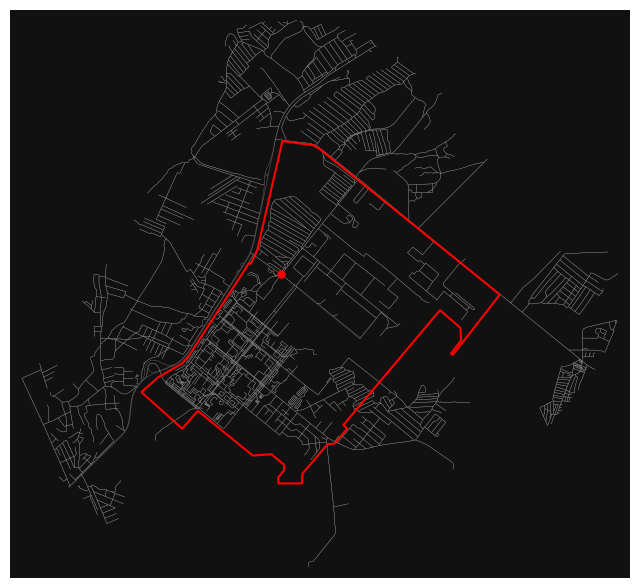

In [34]:
# Печать карты
nodes = ox.graph_to_gdfs(G, edges=False)

fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
area.boundary.plot(ax=ax, color='r')
nodes.loc[best_nodes].plot(ax=ax, markersize=25, color='red')

In [ ]:
# Печать карты
nodes = ox.graph_to_gdfs(G, edges=False)
# ax = nodes[nodes['nearest'].notna()].plot(markersize=1, column='route_times')
fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
area.boundary.plot(ax=ax, color='r')
nodes.loc[best_nodes].plot(ax=ax, markersize=25, color='red')

### Поиск узлов со слабой связностью

In [3]:
G = load_G()

In [13]:
for i, node in enumerate(G.nodes()):
    times, _ = FirstArrivalUnitState()(env=G, points=[node])
    print(i, end='\r')
    if len(times) / G.number_of_nodes()  < 0.1:
        print(node, len(times), round(len(times)/G.number_of_nodes(), 2))

2517534521 1 0.0
2517534589 1 0.0
3981463578 6 0.0
3981463580 6 0.0
3981463582 6 0.0
3981463583 6 0.0
3981463585 6 0.0
3981463586 6 0.0
5574211404 1 0.0
